# Lab 4: Temporal Difference Learning
**MSDS 684 — Reinforcement Learning | Morgan Cooper**

**Reading:** Sutton & Barto (2018), Chapter 6 — Temporal-Difference Learning

---
## Part 1: Environment Setup & Exploration

**Goal:** Understand CliffWalking-v1 before writing any algorithms.

CliffWalking is a 4×12 gridworld (Sutton & Barto, Example 6.6). The agent starts at the bottom-left and must reach the bottom-right goal. The bottom edge between start and goal is a "cliff" — stepping on it gives -100 reward and resets the agent to start. Every other step gives -1.

**Key environment details to verify:**
- **State space:** 48 discrete states (4 rows × 12 columns), represented as a single integer
- **Action space:** 4 discrete actions (0=up, 1=right, 2=down, 3=left)
- **Reward structure:** -1 per step, -100 for cliff (resets to start)
- **Termination:** reaching the goal state (state 47, bottom-right corner)

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

# Reproducibility
np.random.seed(42)

# Plot styling
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
})


In [2]:
# Create the environment
env = gym.make("CliffWalking-v1")

# Inspect the spaces
n_states = env.observation_space.n
n_actions = env.action_space.n
print(f"Number of states:  {n_states}")
print(f"Number of actions: {n_actions}")
print(f"Action mapping:    0=up, 1=right, 2=down, 3=left")

# Reset and see what we get back
state, info = env.reset()
print(f"\nInitial state: {state}")
print(f"As grid position: row={state // 12}, col={state % 12}")

# Take a few steps to see the reward structure
print("\n--- Sample transitions ---")
for action, name in [(0, "up"), (1, "right"), (2, "down")]:
    env.reset()
    next_state, reward, terminated, truncated, info = env.step(action)
    row, col = next_state // 12, next_state % 12
    print(f"Action: {name:5s} → state={next_state} (row={row}, col={col}), "
          f"reward={reward}, terminated={terminated}")

# Step into the cliff to see the -100 penalty
# Go up first, then right (to be above the cliff), then down into it
env.reset()
env.step(0)  # up to row 2, col 0 → state 24
next_state, reward, terminated, truncated, info = env.step(1)  # right to state 25
print(f"\nAbove cliff at state {next_state} (row={next_state//12}, col={next_state%12})")
next_state, reward, terminated, truncated, info = env.step(2)  # down into cliff
print(f"Step down into cliff → state={next_state} (reset to start), "
      f"reward={reward}, terminated={terminated}")

env.close()

Number of states:  48
Number of actions: 4
Action mapping:    0=up, 1=right, 2=down, 3=left

Initial state: 36
As grid position: row=3, col=0

--- Sample transitions ---
Action: up    → state=24 (row=2, col=0), reward=-1, terminated=False
Action: right → state=36 (row=3, col=0), reward=-100, terminated=False
Action: down  → state=36 (row=3, col=0), reward=-1, terminated=False

Above cliff at state 25 (row=2, col=1)
Step down into cliff → state=36 (reset to start), reward=-100, terminated=False


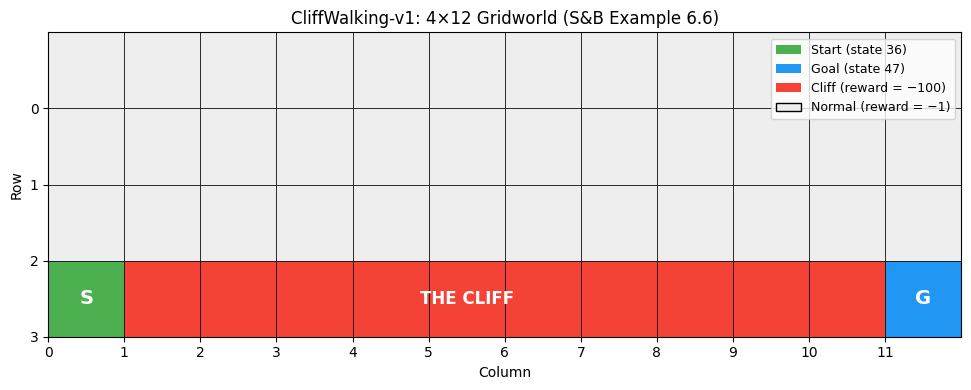

In [3]:
# Grid constants (reused in later visualizations)
NROWS, NCOLS = 4, 12
START = 36       # row=3, col=0
GOAL = 47        # row=3, col=11
CLIFF = list(range(37, 47))  # states 37-46 (row=3, cols 1-10)

fig, ax = plt.subplots(figsize=(12, 4))

for s in range(NROWS * NCOLS):
    row, col = s // NCOLS, s % NCOLS
    y = (NROWS - 1) - row  # flip so row 0 is at top

    if s == START:
        color, label = "#4CAF50", "S"
    elif s == GOAL:
        color, label = "#2196F3", "G"
    elif s in CLIFF:
        color, label = "#F44336", ""
    else:
        color, label = "#EEEEEE", ""

    rect = Rectangle((col, y), 1, 1, facecolor=color, edgecolor="black", linewidth=0.5)
    ax.add_patch(rect)
    if label:
        ax.text(col + 0.5, y + 0.5, label, ha="center", va="center",
                fontsize=14, fontweight="bold", color="white")

ax.text(5.5, 0.5, "THE CLIFF", ha="center", va="center",
        fontsize=12, fontweight="bold", color="white")

ax.set_xlim(0, NCOLS)
ax.set_ylim(0, NROWS)
ax.set_xticks(range(NCOLS))
ax.set_yticks(range(NROWS))
ax.set_xticklabels([str(x) for x in range(NCOLS)])
ax.set_yticklabels([str(x) for x in reversed(range(NROWS))])
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_title("CliffWalking-v1: 4×12 Gridworld (S&B Example 6.6)")
ax.set_aspect("equal")
ax.grid(False)

legend_elements = [
    mpatches.Patch(facecolor="#4CAF50", label="Start (state 36)"),
    mpatches.Patch(facecolor="#2196F3", label="Goal (state 47)"),
    mpatches.Patch(facecolor="#F44336", label="Cliff (reward = −100)"),
    mpatches.Patch(facecolor="#EEEEEE", edgecolor="black", label="Normal (reward = −1)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

---
## Part 2: SARSA — On-Policy TD Control

**Goal:** Implement SARSA and understand why on-policy learning produces a "safe" path.

### The SARSA Update Rule
SARSA updates Q-values using the action the agent *actually takes* next:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \right]$$

The name comes from the tuple $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$ used in each update.

### Why "safe path"?
Because SARSA is **on-policy**, it evaluates the epsilon-greedy policy it's actually following. Near the cliff, random exploratory actions can cause -100 falls. SARSA learns that the cliff-adjacent states are dangerous *under its own behavior* and routes the agent along the safer top path (S&B Section 6.4).

### Implementation checklist:
- [ ] Initialize Q-table as `np.zeros((n_states, n_actions))`
- [ ] Epsilon-greedy action selection with `np.argmax()` and `np.random.choice()`
- [ ] Online update after each `env.step()` — not after episodes
- [ ] Handle terminal states: when `terminated=True`, next state value = 0

In [4]:
def epsilon_greedy(Q, state, epsilon, n_actions):
    """Select action using epsilon-greedy policy.
    
    With probability epsilon: random action (explore)
    With probability 1-epsilon: best action from Q-table (exploit)
    """
    if np.random.random() < epsilon:
        return np.random.choice(n_actions)
    else:
        return np.argmax(Q[state])

In [5]:
def sarsa(env, n_episodes=1000, alpha=0.5, gamma=1.0, epsilon=0.1, seed=None):
    """SARSA: On-policy TD control.
    
    Updates Q toward the action actually taken next (on-policy).
    Returns the Q-table and array of total rewards per episode.
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))
    rewards_per_episode = np.zeros(n_episodes)
    
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep if seed is not None else None)
        action = epsilon_greedy(Q, state, epsilon, n_actions)
        total_reward = 0
        
        while True:
            # Take action, observe result
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            
            # Choose next action using epsilon-greedy (SARSA needs this BEFORE update)
            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions)
            
            # TD update: target uses Q[next_state, next_action] (the action we WILL take)
            if terminated:
                td_target = reward  # no future value at terminal state
            else:
                td_target = reward + gamma * Q[next_state, next_action]
            
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error
            
            # Move to next state and action
            state = next_state
            action = next_action
            
            if terminated or truncated:
                break
        
        rewards_per_episode[ep] = total_reward
    
    return Q, rewards_per_episode

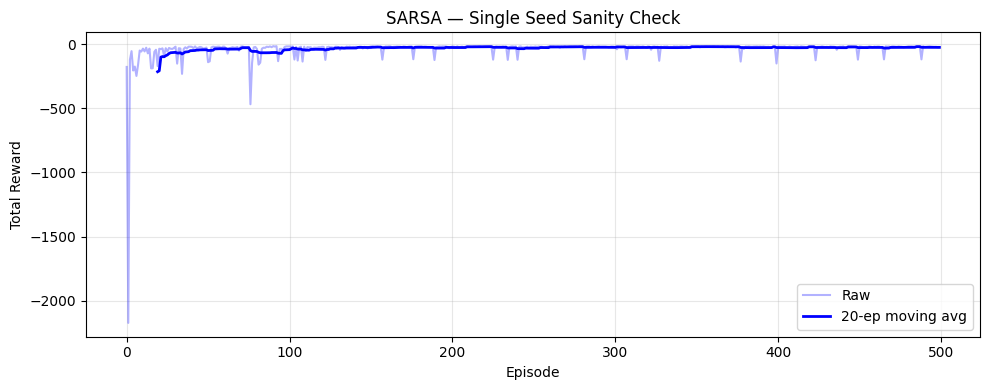

Mean reward (last 100 episodes): -24.1


In [6]:
# Quick sanity check: single run of SARSA
env = gym.make("CliffWalking-v1")
Q_sarsa, rewards_sarsa = sarsa(env, n_episodes=500, alpha=0.5, epsilon=0.1, seed=42)
env.close()

# Plot reward per episode
plt.figure(figsize=(10, 4))
plt.plot(rewards_sarsa, alpha=0.3, color="blue", label="Raw")
# Smoothed with rolling average
window = 20
smoothed = np.convolve(rewards_sarsa, np.ones(window)/window, mode="valid")
plt.plot(range(window-1, len(rewards_sarsa)), smoothed, color="blue", linewidth=2, label=f"{window}-ep moving avg")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("SARSA — Single Seed Sanity Check")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean reward (last 100 episodes): {rewards_sarsa[-100:].mean():.1f}")

---
## Part 3: Q-Learning — Off-Policy TD Control

**Goal:** Implement Q-learning and understand why off-policy learning finds the "optimal but risky" path.

### The Q-Learning Update Rule
Q-learning updates Q-values using the *best possible* next action, regardless of what the agent actually does:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t) \right]$$

The only difference from SARSA: `Q(S_{t+1}, A_{t+1})` becomes `max_a Q(S_{t+1}, a)`.

### Why "optimal but risky"?
Q-learning is **off-policy** — it learns the value of the greedy policy while following epsilon-greedy. The greedy policy never randomly walks off the cliff, so Q-learning doesn't penalize cliff-adjacent states. It learns the optimal shortest path along the cliff edge. But *during training*, the agent still explores and falls off, so online rewards are worse than SARSA (S&B Section 6.5, Figure 6.4).

### Implementation checklist:
- [ ] Same structure as SARSA
- [ ] Key change: TD target uses `np.max(Q[next_state])` instead of `Q[next_state, next_action]`
- [ ] Action selection is still epsilon-greedy (behavior policy)
- [ ] The learned Q-values reflect the greedy (target) policy

In [7]:
def q_learning(env, n_episodes=1000, alpha=0.5, gamma=1.0, epsilon=0.1, seed=None):
    """Q-Learning: Off-policy TD control.
    
    Updates Q toward the best possible next action (off-policy).
    Returns the Q-table and array of total rewards per episode.
    """
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))
    rewards_per_episode = np.zeros(n_episodes)
    
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep if seed is not None else None)
        total_reward = 0
        
        while True:
            # Choose action using epsilon-greedy (behavior policy)
            action = epsilon_greedy(Q, state, epsilon, n_actions)
            
            # Take action, observe result
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            
            # TD update: target uses max Q[next_state] (the BEST action, not what we'll do)
            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * np.max(Q[next_state])
            
            td_error = td_target - Q[state, action]
            Q[state, action] += alpha * td_error
            
            state = next_state
            
            if terminated or truncated:
                break
        
        rewards_per_episode[ep] = total_reward
    
    return Q, rewards_per_episode

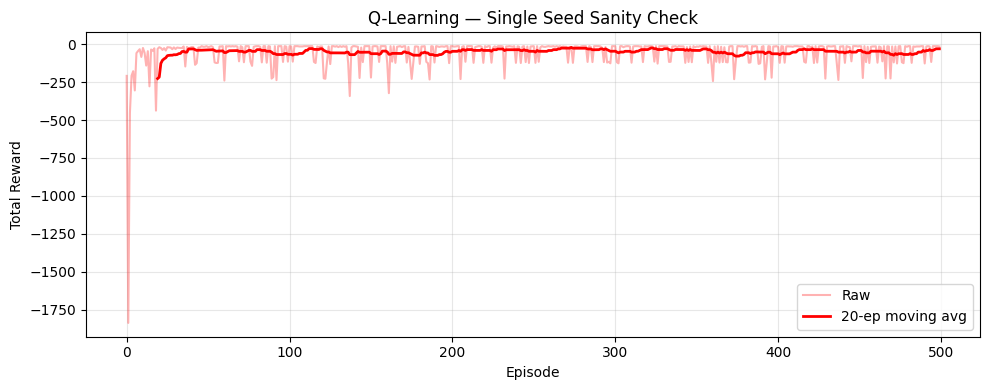

Mean reward (last 100 episodes): -46.5


In [8]:
# Quick sanity check: single run of Q-learning
env = gym.make("CliffWalking-v1")
Q_qlearn, rewards_qlearn = q_learning(env, n_episodes=500, alpha=0.5, epsilon=0.1, seed=42)
env.close()

# Plot reward per episode
plt.figure(figsize=(10, 4))
plt.plot(rewards_qlearn, alpha=0.3, color="red", label="Raw")
window = 20
smoothed = np.convolve(rewards_qlearn, np.ones(window)/window, mode="valid")
plt.plot(range(window-1, len(rewards_qlearn)), smoothed, color="red", linewidth=2, label=f"{window}-ep moving avg")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning — Single Seed Sanity Check")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean reward (last 100 episodes): {rewards_qlearn[-100:].mean():.1f}")

---
## Part 4: Multi-Seed Experiments & Learning Curves

**Goal:** Run both algorithms across 30+ random seeds and plot learning curves with 95% confidence intervals.

### Why multiple seeds?
A single run of either algorithm is noisy — the agent might get lucky or unlucky with exploration. Running 30+ seeds and averaging gives us the **expected** performance curve. The 95% CI shows how much variance there is across runs.

### What to expect (S&B Figure 6.4):
- **SARSA** should show higher (less negative) online rewards — it avoids the cliff
- **Q-learning** should show lower online rewards — it falls off the cliff during exploration
- Both should converge, but Q-learning's *greedy policy* will achieve the optimal -13 reward (shortest path), while SARSA's greedy policy achieves ~-17 (safe path)

### Implementation notes:
- Store rewards per episode for each seed: shape `(n_seeds, n_episodes)`
- Mean across seeds: `np.mean(rewards, axis=0)`
- 95% CI: `mean ± 1.96 * std / sqrt(n_seeds)`
- Use `plt.fill_between()` for the CI band

In [9]:
# Run both algorithms across 30 seeds, 1000 episodes each
N_SEEDS = 30
N_EPISODES = 1000
ALPHA = 0.5
EPSILON = 0.1

sarsa_all_rewards = np.zeros((N_SEEDS, N_EPISODES))
qlearn_all_rewards = np.zeros((N_SEEDS, N_EPISODES))

for i in range(N_SEEDS):
    seed = i * 100
    
    env = gym.make("CliffWalking-v1")
    _, rewards = sarsa(env, n_episodes=N_EPISODES, alpha=ALPHA, epsilon=EPSILON, seed=seed)
    sarsa_all_rewards[i] = rewards
    env.close()
    
    env = gym.make("CliffWalking-v1")
    _, rewards = q_learning(env, n_episodes=N_EPISODES, alpha=ALPHA, epsilon=EPSILON, seed=seed)
    qlearn_all_rewards[i] = rewards
    env.close()

print(f"Completed {N_SEEDS} seeds × {N_EPISODES} episodes for both algorithms.")

Completed 30 seeds × 1000 episodes for both algorithms.


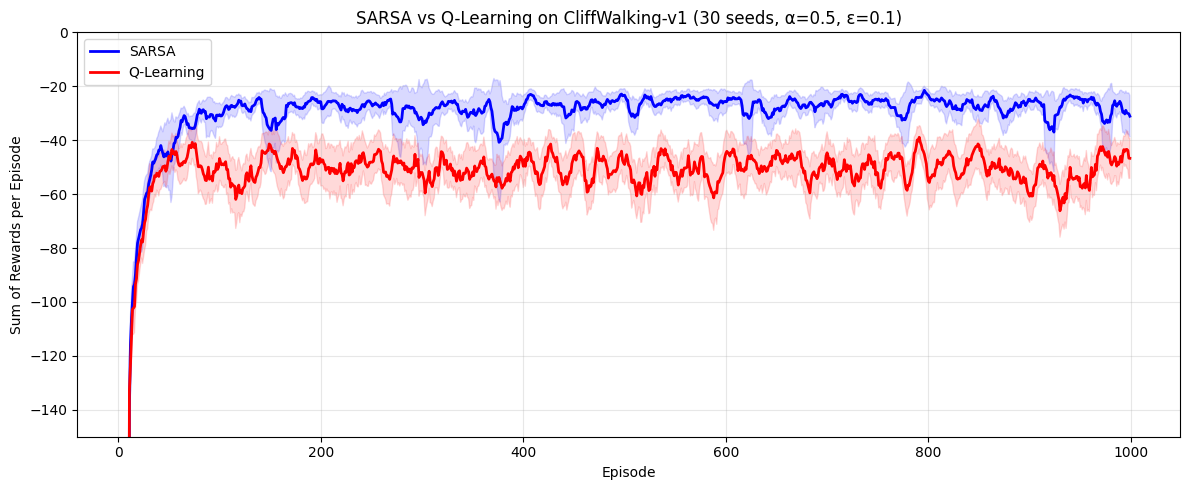

SARSA   — mean last 100 eps: -28.0
Q-Learn — mean last 100 eps: -51.6


In [10]:
# Compute mean and 95% confidence intervals across seeds
def compute_stats(all_rewards, window=10):
    """Smooth each seed's rewards, then compute mean and 95% CI across seeds."""
    n_seeds, n_eps = all_rewards.shape
    # Smooth each seed individually
    smoothed = np.array([
        np.convolve(all_rewards[i], np.ones(window)/window, mode="valid")
        for i in range(n_seeds)
    ])
    mean = np.mean(smoothed, axis=0)
    std = np.std(smoothed, axis=0)
    ci = 1.96 * std / np.sqrt(n_seeds)
    episodes = np.arange(window - 1, n_eps)
    return episodes, mean, ci

episodes_s, mean_s, ci_s = compute_stats(sarsa_all_rewards)
episodes_q, mean_q, ci_q = compute_stats(qlearn_all_rewards)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(episodes_s, mean_s, color="blue", linewidth=2, label="SARSA")
ax.fill_between(episodes_s, mean_s - ci_s, mean_s + ci_s, color="blue", alpha=0.15)

ax.plot(episodes_q, mean_q, color="red", linewidth=2, label="Q-Learning")
ax.fill_between(episodes_q, mean_q - ci_q, mean_q + ci_q, color="red", alpha=0.15)

ax.set_xlabel("Episode")
ax.set_ylabel("Sum of Rewards per Episode")
ax.set_title(f"SARSA vs Q-Learning on CliffWalking-v1 ({N_SEEDS} seeds, α={ALPHA}, ε={EPSILON})")
ax.legend()
ax.set_ylim(-150, 0)
plt.tight_layout()
plt.show()

print(f"SARSA   — mean last 100 eps: {sarsa_all_rewards[:, -100:].mean():.1f}")
print(f"Q-Learn — mean last 100 eps: {qlearn_all_rewards[:, -100:].mean():.1f}")

---
## Part 5: Hyperparameter Experiments

**Goal:** Experiment with different step-size (alpha) and exploration schedules (epsilon-decay) to understand their effects.

### Step-size (alpha)
- Controls how much new information overrides old Q-values
- Too high → unstable, oscillating values
- Too low → slow convergence
- Try: alpha = {0.1, 0.3, 0.5}

### Epsilon-decay schedules
- Constant epsilon: always explores at the same rate
- Linear decay: epsilon decreases linearly from start to min over N episodes
- Exponential decay: `epsilon = max(epsilon_min, epsilon * decay_rate)`
- Key question: does decaying epsilon change whether SARSA takes the safe or optimal path?

### What to look for:
- How does alpha affect learning speed and stability for each algorithm?
- Does epsilon-decay cause SARSA to eventually learn the cliff-edge path (since it explores less)?
- Which combination gives the best online performance? Best final policy?

In [11]:
# Run both algorithms with different alpha values
ALPHAS = [0.1, 0.3, 0.5]
N_SEEDS_HP = 20  # fewer seeds to keep runtime reasonable
N_EPISODES_HP = 1000

alpha_results = {}

for alpha in ALPHAS:
    sarsa_rewards = np.zeros((N_SEEDS_HP, N_EPISODES_HP))
    qlearn_rewards = np.zeros((N_SEEDS_HP, N_EPISODES_HP))
    
    for i in range(N_SEEDS_HP):
        seed = i * 100
        
        env = gym.make("CliffWalking-v1")
        _, rewards = sarsa(env, n_episodes=N_EPISODES_HP, alpha=alpha, epsilon=0.1, seed=seed)
        sarsa_rewards[i] = rewards
        env.close()
        
        env = gym.make("CliffWalking-v1")
        _, rewards = q_learning(env, n_episodes=N_EPISODES_HP, alpha=alpha, epsilon=0.1, seed=seed)
        qlearn_rewards[i] = rewards
        env.close()
    
    alpha_results[alpha] = {"sarsa": sarsa_rewards, "qlearn": qlearn_rewards}
    print(f"α={alpha} done.")

print("Alpha experiment complete.")

α=0.1 done.
α=0.3 done.
α=0.5 done.
Alpha experiment complete.


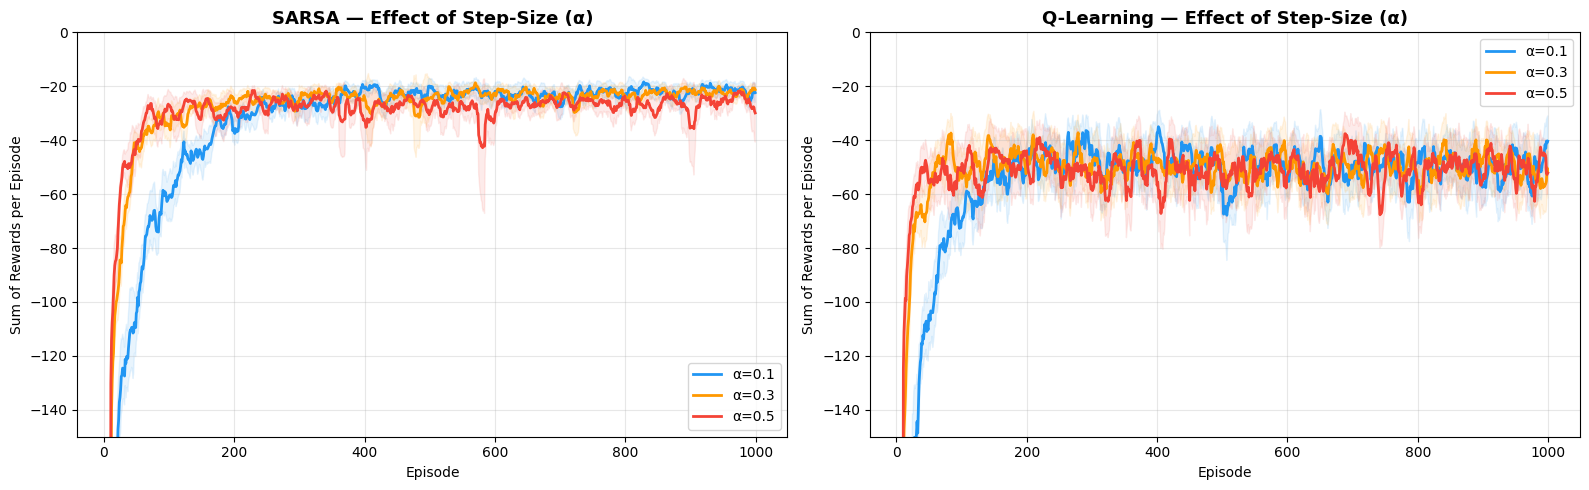

Mean reward (last 100 episodes):
  α=0.1: SARSA=-21.5, Q-Learning=-49.2
  α=0.3: SARSA=-22.3, Q-Learning=-50.1
  α=0.5: SARSA=-25.5, Q-Learning=-50.0


In [12]:
# Plot alpha comparison
colors_alpha = {0.1: "#2196F3", 0.3: "#FF9800", 0.5: "#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, algo_key, algo_name in [(axes[0], "sarsa", "SARSA"),
                                  (axes[1], "qlearn", "Q-Learning")]:
    for alpha in ALPHAS:
        episodes, mean, ci = compute_stats(alpha_results[alpha][algo_key])
        c = colors_alpha[alpha]
        ax.plot(episodes, mean, color=c, linewidth=2, label=f"α={alpha}")
        ax.fill_between(episodes, mean - ci, mean + ci, color=c, alpha=0.1)
    
    ax.set_xlabel("Episode")
    ax.set_ylabel("Sum of Rewards per Episode")
    ax.set_title(f"{algo_name} — Effect of Step-Size (α)", fontsize=13, fontweight="bold")
    ax.legend()
    ax.set_ylim(-150, 0)

plt.tight_layout()
plt.show()

# Print final performance for each
print("Mean reward (last 100 episodes):")
for alpha in ALPHAS:
    s_mean = alpha_results[alpha]["sarsa"][:, -100:].mean()
    q_mean = alpha_results[alpha]["qlearn"][:, -100:].mean()
    print(f"  α={alpha}: SARSA={s_mean:.1f}, Q-Learning={q_mean:.1f}")

In [13]:
def sarsa_decay(env, n_episodes=1000, alpha=0.5, gamma=1.0,
                epsilon_start=1.0, epsilon_min=0.01, decay_type="constant", seed=None):
    """SARSA with configurable epsilon-decay schedule."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))
    rewards_per_episode = np.zeros(n_episodes)
    
    for ep in range(n_episodes):
        # Compute epsilon for this episode
        if decay_type == "constant":
            epsilon = epsilon_start
        elif decay_type == "linear":
            epsilon = max(epsilon_min, epsilon_start - (epsilon_start - epsilon_min) * ep / n_episodes)
        elif decay_type == "exponential":
            decay_rate = (epsilon_min / epsilon_start) ** (1 / n_episodes)
            epsilon = max(epsilon_min, epsilon_start * (decay_rate ** ep))
        
        state, _ = env.reset(seed=seed + ep if seed is not None else None)
        action = epsilon_greedy(Q, state, epsilon, n_actions)
        total_reward = 0
        
        while True:
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            next_action = epsilon_greedy(Q, next_state, epsilon, n_actions)
            
            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * Q[next_state, next_action]
            
            Q[state, action] += alpha * (td_target - Q[state, action])
            state = next_state
            action = next_action
            
            if terminated or truncated:
                break
        
        rewards_per_episode[ep] = total_reward
    
    return Q, rewards_per_episode


def q_learning_decay(env, n_episodes=1000, alpha=0.5, gamma=1.0,
                     epsilon_start=1.0, epsilon_min=0.01, decay_type="constant", seed=None):
    """Q-Learning with configurable epsilon-decay schedule."""
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    Q = np.zeros((n_states, n_actions))
    rewards_per_episode = np.zeros(n_episodes)
    
    for ep in range(n_episodes):
        if decay_type == "constant":
            epsilon = epsilon_start
        elif decay_type == "linear":
            epsilon = max(epsilon_min, epsilon_start - (epsilon_start - epsilon_min) * ep / n_episodes)
        elif decay_type == "exponential":
            decay_rate = (epsilon_min / epsilon_start) ** (1 / n_episodes)
            epsilon = max(epsilon_min, epsilon_start * (decay_rate ** ep))
        
        state, _ = env.reset(seed=seed + ep if seed is not None else None)
        total_reward = 0
        
        while True:
            action = epsilon_greedy(Q, state, epsilon, n_actions)
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            
            if terminated:
                td_target = reward
            else:
                td_target = reward + gamma * np.max(Q[next_state])
            
            Q[state, action] += alpha * (td_target - Q[state, action])
            state = next_state
            
            if terminated or truncated:
                break
        
        rewards_per_episode[ep] = total_reward
    
    return Q, rewards_per_episode


# Run epsilon-decay experiments
DECAY_TYPES = ["constant", "linear", "exponential"]
N_SEEDS_DECAY = 20

decay_results = {}

for decay_type in DECAY_TYPES:
    sarsa_rewards = np.zeros((N_SEEDS_DECAY, N_EPISODES_HP))
    qlearn_rewards = np.zeros((N_SEEDS_DECAY, N_EPISODES_HP))
    
    eps_start = 0.1 if decay_type == "constant" else 1.0
    
    for i in range(N_SEEDS_DECAY):
        seed = i * 100
        
        env = gym.make("CliffWalking-v1")
        _, rewards = sarsa_decay(env, n_episodes=N_EPISODES_HP, alpha=0.5,
                                  epsilon_start=eps_start, epsilon_min=0.01,
                                  decay_type=decay_type, seed=seed)
        sarsa_rewards[i] = rewards
        env.close()
        
        env = gym.make("CliffWalking-v1")
        _, rewards = q_learning_decay(env, n_episodes=N_EPISODES_HP, alpha=0.5,
                                       epsilon_start=eps_start, epsilon_min=0.01,
                                       decay_type=decay_type, seed=seed)
        qlearn_rewards[i] = rewards
        env.close()
    
    decay_results[decay_type] = {"sarsa": sarsa_rewards, "qlearn": qlearn_rewards}
    print(f"{decay_type} done.")

print("Epsilon-decay experiment complete.")

constant done.
linear done.
exponential done.
Epsilon-decay experiment complete.


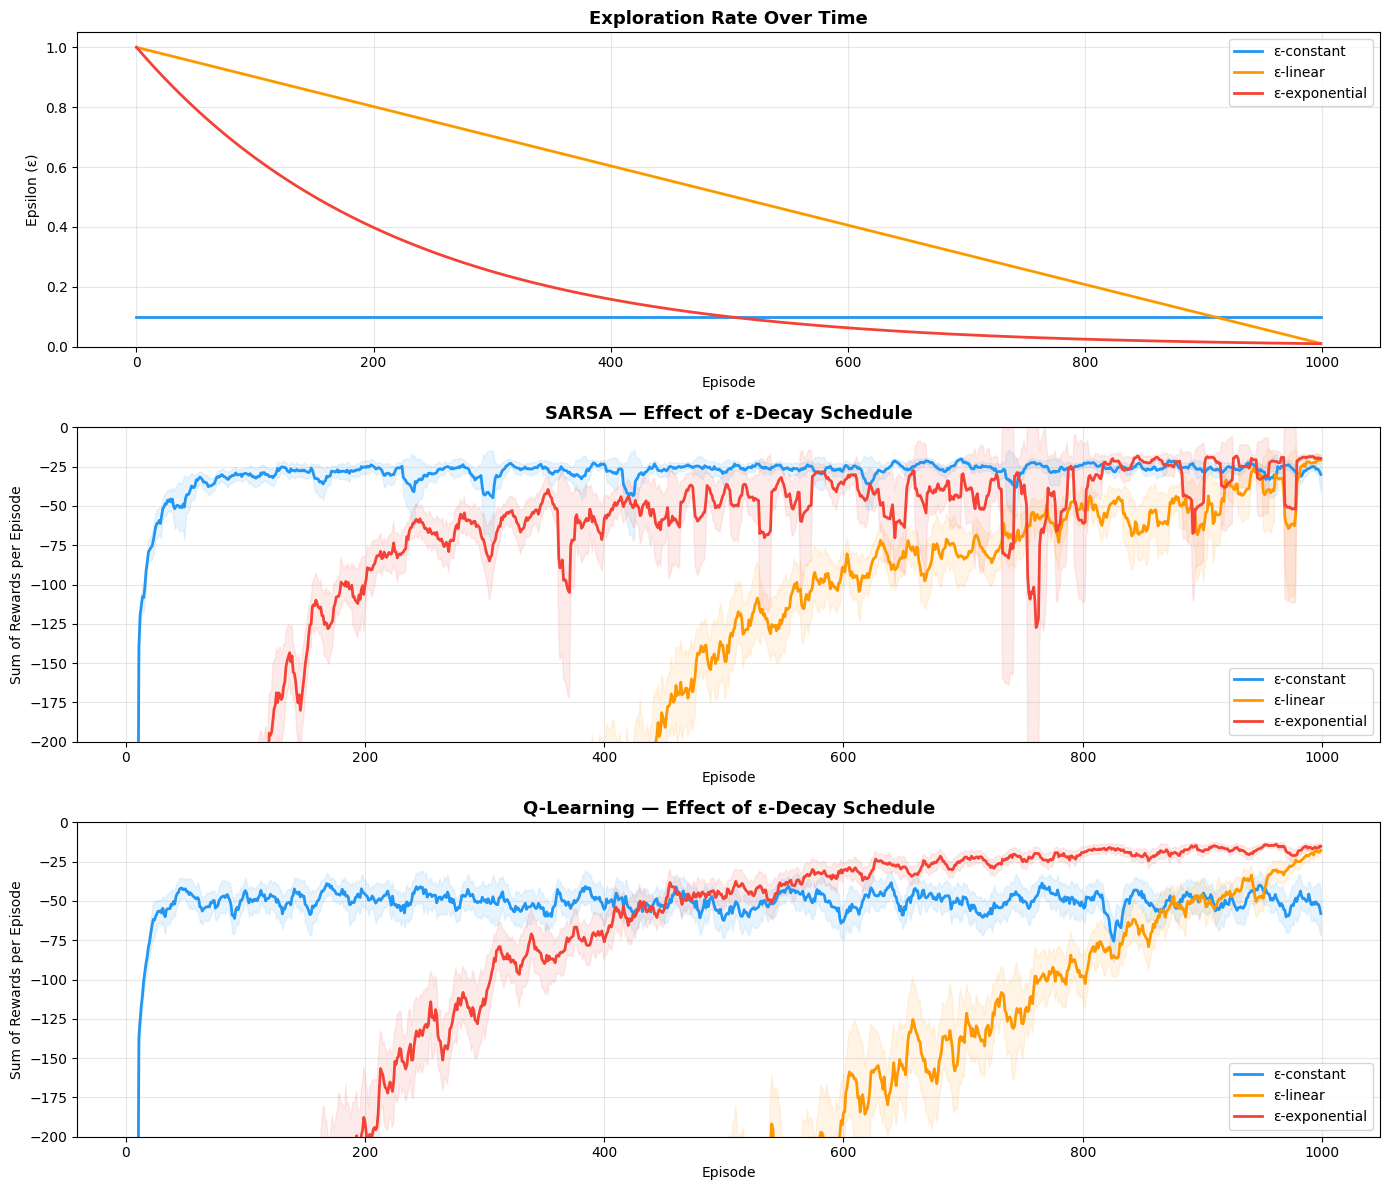

Mean reward (last 100 episodes):
  ε-constant    : SARSA=-27.3, Q-Learning=-50.1
  ε-linear      : SARSA=-37.8, Q-Learning=-35.4
  ε-exponential : SARSA=-26.5, Q-Learning=-16.8


In [14]:
# Full picture: epsilon schedule + reward curves stacked vertically
colors_decay = {"constant": "#2196F3", "linear": "#FF9800", "exponential": "#F44336"}

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Top: epsilon schedules over time ---
ax_eps = axes[0]
episodes_range = np.arange(N_EPISODES_HP)
for decay_type in DECAY_TYPES:
    eps_values = np.zeros(N_EPISODES_HP)
    for ep in range(N_EPISODES_HP):
        if decay_type == "constant":
            eps_values[ep] = 0.1
        elif decay_type == "linear":
            eps_values[ep] = max(0.01, 1.0 - (1.0 - 0.01) * ep / N_EPISODES_HP)
        elif decay_type == "exponential":
            decay_rate = (0.01 / 1.0) ** (1 / N_EPISODES_HP)
            eps_values[ep] = max(0.01, 1.0 * (decay_rate ** ep))
    
    ax_eps.plot(episodes_range, eps_values, color=colors_decay[decay_type],
                linewidth=2, label=f"ε-{decay_type}")

ax_eps.set_xlabel("Episode")
ax_eps.set_ylabel("Epsilon (ε)")
ax_eps.set_title("Exploration Rate Over Time", fontsize=13, fontweight="bold")
ax_eps.legend()
ax_eps.set_ylim(0, 1.05)

# --- Middle: SARSA ---
ax_s = axes[1]
for decay_type in DECAY_TYPES:
    episodes, mean, ci = compute_stats(decay_results[decay_type]["sarsa"])
    c = colors_decay[decay_type]
    ax_s.plot(episodes, mean, color=c, linewidth=2, label=f"ε-{decay_type}")
    ax_s.fill_between(episodes, mean - ci, mean + ci, color=c, alpha=0.1)
ax_s.set_xlabel("Episode")
ax_s.set_ylabel("Sum of Rewards per Episode")
ax_s.set_title("SARSA — Effect of ε-Decay Schedule", fontsize=13, fontweight="bold")
ax_s.legend()
ax_s.set_ylim(-200, 0)

# --- Bottom: Q-Learning ---
ax_q = axes[2]
for decay_type in DECAY_TYPES:
    episodes, mean, ci = compute_stats(decay_results[decay_type]["qlearn"])
    c = colors_decay[decay_type]
    ax_q.plot(episodes, mean, color=c, linewidth=2, label=f"ε-{decay_type}")
    ax_q.fill_between(episodes, mean - ci, mean + ci, color=c, alpha=0.1)
ax_q.set_xlabel("Episode")
ax_q.set_ylabel("Sum of Rewards per Episode")
ax_q.set_title("Q-Learning — Effect of ε-Decay Schedule", fontsize=13, fontweight="bold")
ax_q.legend()
ax_q.set_ylim(-200, 0)

plt.tight_layout()
plt.show()

# Print final performance
print("Mean reward (last 100 episodes):")
for decay_type in DECAY_TYPES:
    s_mean = decay_results[decay_type]["sarsa"][:, -100:].mean()
    q_mean = decay_results[decay_type]["qlearn"][:, -100:].mean()
    print(f"  ε-{decay_type:12s}: SARSA={s_mean:.1f}, Q-Learning={q_mean:.1f}")


---
## Part 6: Visualizations — Policy Arrows, Trajectories & Heatmaps

**Goal:** Create the required visualizations that reveal the behavioral differences between SARSA and Q-learning.

### Visualization 1: Q-Value Arrow Grids
- For each state, draw an arrow pointing in the direction of the greedy action (`argmax Q[s]`)
- SARSA's arrows should route *around* the cliff (safe path)
- Q-learning's arrows should route *along* the cliff edge (optimal path)

### Visualization 2: Trajectory Plots
- Run the learned greedy policy (no exploration) and trace the path on the grid
- Shows the actual behavioral difference between the two learned policies

### Visualization 3: Value Function Heatmaps
- Plot `max_a Q(s, a)` for each state as a color on the grid
- Should show that Q-learning assigns higher value to cliff-adjacent states
- SARSA should show lower values near the cliff (it "knows" it's dangerous under epsilon-greedy)

In [15]:
def state_to_grid(state):
    """Convert state integer to (row, col) tuple."""
    return state // NCOLS, state % NCOLS

def draw_grid(ax, title):
    """Draw the base CliffWalking grid on an axis."""
    for s in range(NROWS * NCOLS):
        row, col = state_to_grid(s)
        y = (NROWS - 1) - row
        if s == START:
            color = "#4CAF50"
        elif s == GOAL:
            color = "#2196F3"
        elif s in CLIFF:
            color = "#F44336"
        else:
            color = "#EEEEEE"
        rect = Rectangle((col, y), 1, 1, facecolor=color, edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
    
    ax.set_xlim(0, NCOLS)
    ax.set_ylim(0, NROWS)
    ax.set_xticks(range(NCOLS))
    ax.set_yticks(range(NROWS))
    ax.set_xticklabels([str(x) for x in range(NCOLS)])
    ax.set_yticklabels([str(x) for x in reversed(range(NROWS))])
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(False)

def greedy_rollout(Q, env, max_steps=200):
    """Execute greedy policy, return visited states. Detects loops."""
    state, _ = env.reset()
    trajectory = [state]
    visited = {state}
    for _ in range(max_steps):
        action = np.argmax(Q[state])
        next_state, _, terminated, truncated, _ = env.step(action)
        trajectory.append(next_state)
        if terminated or truncated:
            break
        if next_state in visited:
            print(f"  WARNING: Loop detected at state {next_state}!")
            break
        visited.add(next_state)
        state = next_state
    return trajectory

# Train fresh Q-tables for visualization
# Reset random state and train for 2000 episodes to ensure convergence
np.random.seed(42)

env = gym.make("CliffWalking-v1")
Q_sarsa_vis, _ = sarsa(env, n_episodes=2000, alpha=0.5, epsilon=0.1, seed=42)
env.close()

env = gym.make("CliffWalking-v1")
Q_qlearn_vis, _ = q_learning(env, n_episodes=2000, alpha=0.5, epsilon=0.1, seed=42)
env.close()

# Verify greedy policies reach the goal
for name, Q in [('SARSA', Q_sarsa_vis), ('Q-Learning', Q_qlearn_vis)]:
    env = gym.make("CliffWalking-v1")
    traj = greedy_rollout(Q, env)
    env.close()
    reached = traj[-1] == GOAL
    print(f"{name}: {len(traj)-1} steps, reached goal = {reached}")


SARSA: 17 steps, reached goal = True
Q-Learning: 13 steps, reached goal = True


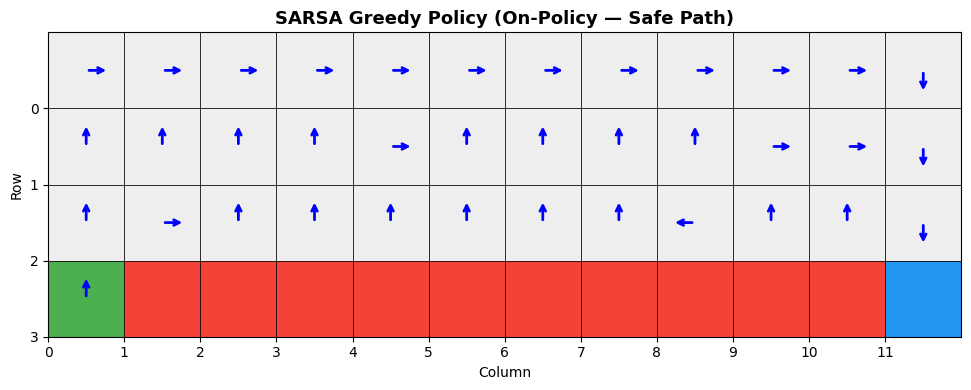

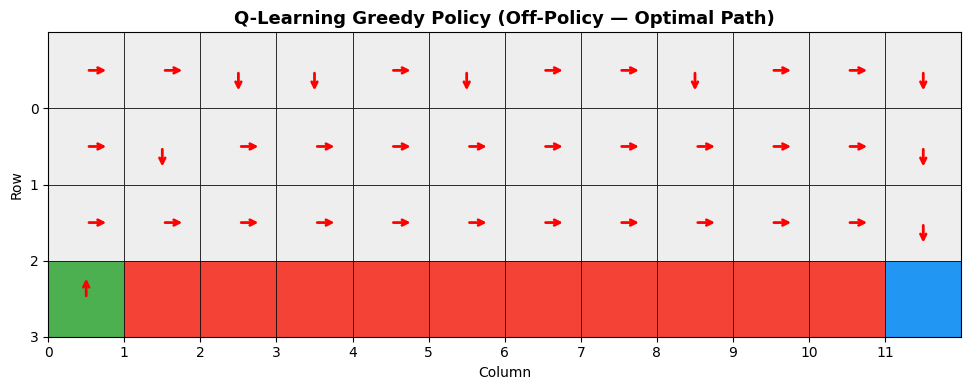

In [16]:
# Greedy policy arrow grids
ARROW_DX = {0: 0, 1: 0.3, 2: 0, 3: -0.3}
ARROW_DY = {0: 0.3, 1: 0, 2: -0.3, 3: 0}

for Q, title, arrow_color in [
    (Q_sarsa_vis, "SARSA Greedy Policy (On-Policy — Safe Path)", "blue"),
    (Q_qlearn_vis, "Q-Learning Greedy Policy (Off-Policy — Optimal Path)", "red")]:
    
    fig, ax = plt.subplots(figsize=(14, 4))
    draw_grid(ax, title)
    
    for s in range(NROWS * NCOLS):
        if s not in CLIFF and s != GOAL:
            row, col = state_to_grid(s)
            y = (NROWS - 1) - row
            best_action = int(np.argmax(Q[s]))
            cx, cy = col + 0.5, y + 0.5
            ax.annotate("", xy=(cx + ARROW_DX[best_action], cy + ARROW_DY[best_action]),
                        xytext=(cx, cy),
                        arrowprops=dict(arrowstyle="->", color=arrow_color, lw=2))
    
    plt.tight_layout()
    plt.show()


SARSA Greedy Trajectory: 17 steps


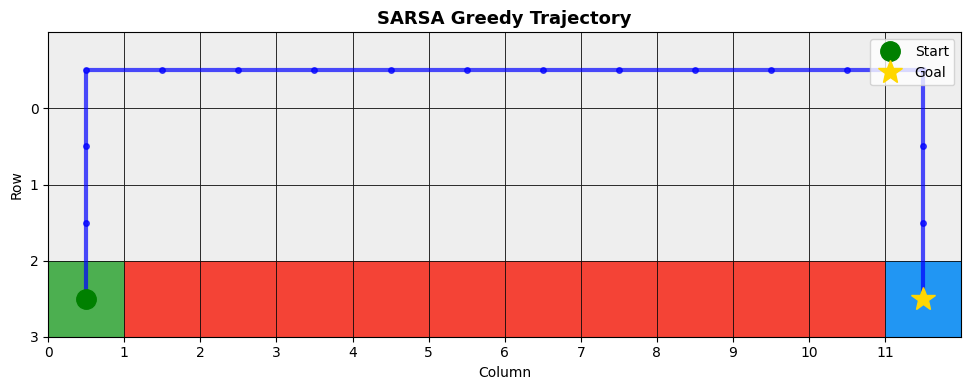

Q-Learning Greedy Trajectory: 13 steps


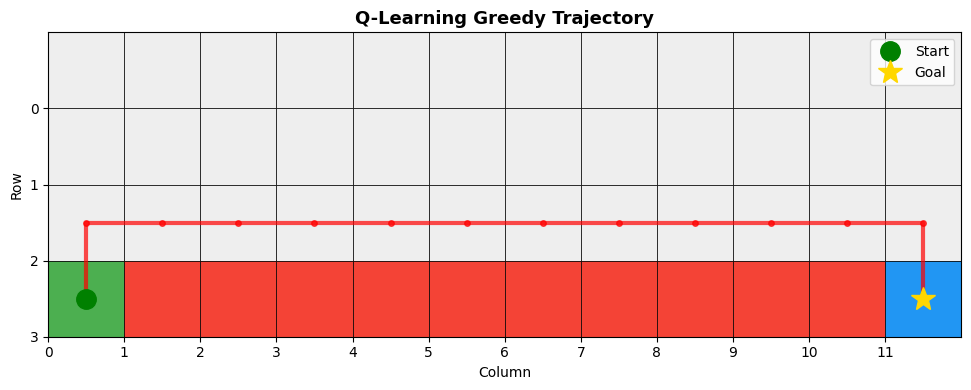

In [17]:
# Greedy policy trajectory rollouts
for Q, title, path_color in [
    (Q_sarsa_vis, "SARSA Greedy Trajectory", "blue"),
    (Q_qlearn_vis, "Q-Learning Greedy Trajectory", "red")]:
    
    env = gym.make("CliffWalking-v1")
    trajectory = greedy_rollout(Q, env)
    env.close()
    
    fig, ax = plt.subplots(figsize=(14, 4))
    draw_grid(ax, title)
    
    # Plot the path as connected line segments
    xs = [state_to_grid(s)[1] + 0.5 for s in trajectory]
    ys = [(NROWS - 1 - state_to_grid(s)[0]) + 0.5 for s in trajectory]
    ax.plot(xs, ys, color=path_color, linewidth=3, alpha=0.7, marker='o', markersize=4)
    
    # Mark start and end
    ax.plot(xs[0], ys[0], "o", color="green", markersize=14, zorder=5, label="Start")
    ax.plot(xs[-1], ys[-1], "*", color="gold", markersize=18, zorder=5, label="Goal")
    ax.legend(loc='upper right')
    
    print(f"{title}: {len(trajectory)-1} steps")
    plt.tight_layout()
    plt.show()


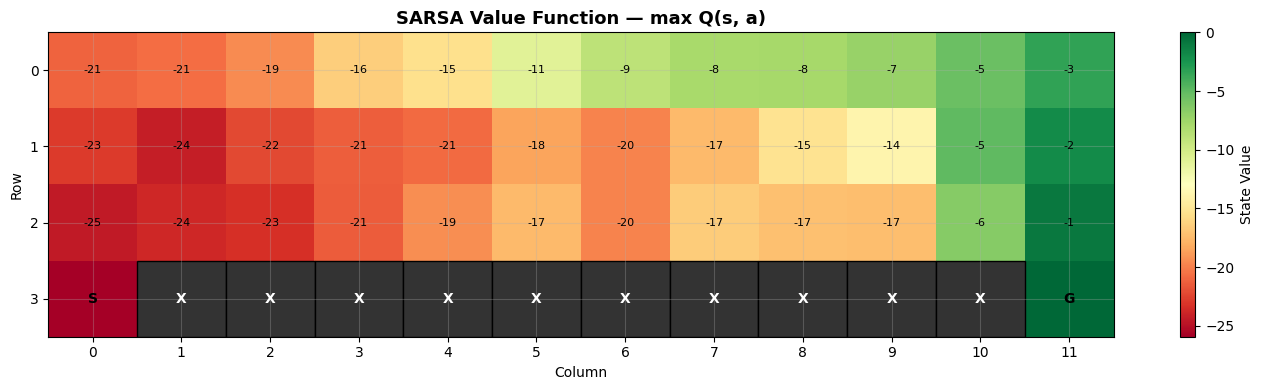

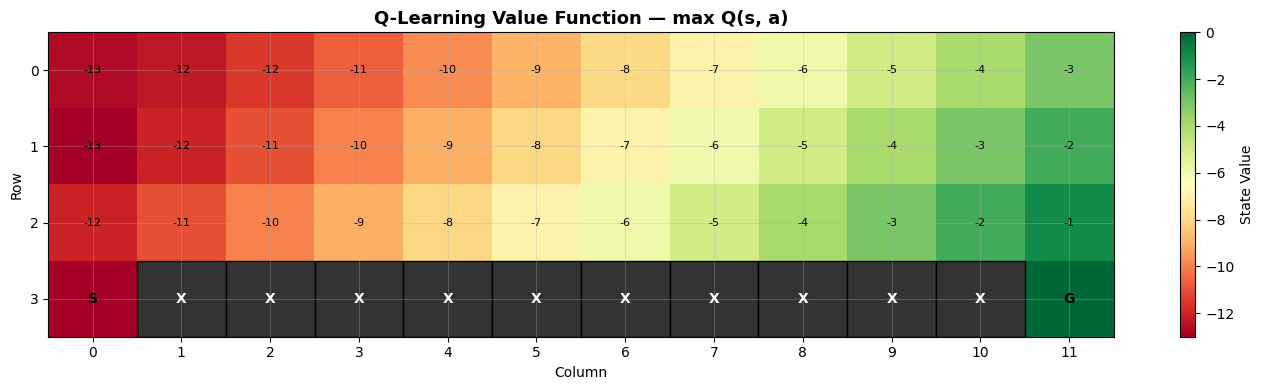

In [18]:
# Value function heatmaps: max_a Q(s, a)
for Q, title in [
    (Q_sarsa_vis, "SARSA Value Function — max Q(s, a)"),
    (Q_qlearn_vis, "Q-Learning Value Function — max Q(s, a)")]:
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # Build value grid
    values = np.zeros((NROWS, NCOLS))
    for s in range(NROWS * NCOLS):
        row, col = state_to_grid(s)
        if s in CLIFF:
            values[row, col] = np.nan
        else:
            values[row, col] = np.max(Q[s])
    
    # Plot heatmap
    cmap = 'RdYlGn'
    im = ax.imshow(values, cmap=cmap, aspect='auto', interpolation='nearest')
    
    # Overlay values as text
    for s in range(NROWS * NCOLS):
        row, col = state_to_grid(s)
        if s == START:
            ax.text(col, row, "S", ha="center", va="center", fontsize=10, fontweight="bold")
        elif s == GOAL:
            ax.text(col, row, "G", ha="center", va="center", fontsize=10, fontweight="bold")
        elif s in CLIFF:
            pass  # handled below
        else:
            ax.text(col, row, f"{values[row, col]:.0f}", ha="center", va="center", fontsize=8)
    
    # Mark cliff cells with dark background
    for s in CLIFF:
        row, col = state_to_grid(s)
        rect = Rectangle((col - 0.5, row - 0.5), 1, 1, facecolor='#333333', edgecolor='black')
        ax.add_patch(rect)
        ax.text(col, row, "X", ha="center", va="center", fontsize=10, color="white", fontweight="bold")
    
    ax.set_xticks(range(NCOLS))
    ax.set_yticks(range(NROWS))
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.colorbar(im, ax=ax, label='State Value')
    plt.tight_layout()
    plt.show()


---
## Part 7: Analysis & Comparison Table

**Goal:** Summarize results quantitatively and connect findings back to theory.


In [19]:
# Compute comparison statistics from the 30-seed experiment (Part 4)

# Mean reward over last 100 episodes (averaged across seeds)
sarsa_final_mean = sarsa_all_rewards[:, -100:].mean()
qlearn_final_mean = qlearn_all_rewards[:, -100:].mean()

# Greedy policy reward (run learned policy with no exploration)
def evaluate_greedy(Q, env, n_eval=50):
    """Run greedy policy n_eval times and return mean reward."""
    rewards = []
    for i in range(n_eval):
        state, _ = env.reset(seed=1000 + i)
        total = 0
        for _ in range(200):
            action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break
            state = next_state
        rewards.append(total)
    return np.mean(rewards)

env = gym.make("CliffWalking-v1")
sarsa_greedy_reward = evaluate_greedy(Q_sarsa_vis, env)
env.close()

env = gym.make("CliffWalking-v1")
qlearn_greedy_reward = evaluate_greedy(Q_qlearn_vis, env)
env.close()

# Greedy trajectory length
env = gym.make("CliffWalking-v1")
sarsa_traj = greedy_rollout(Q_sarsa_vis, env)
env.close()
env = gym.make("CliffWalking-v1")
qlearn_traj = greedy_rollout(Q_qlearn_vis, env)
env.close()

sarsa_steps = len(sarsa_traj) - 1
qlearn_steps = len(qlearn_traj) - 1

# Convergence episode (first episode where 50-ep rolling avg stays above threshold)
def find_convergence(all_rewards, threshold, window=50):
    """Find first episode where rolling avg crosses threshold and stays."""
    mean_rewards = np.mean(all_rewards, axis=0)
    rolling = np.convolve(mean_rewards, np.ones(window)/window, mode='valid')
    for i, val in enumerate(rolling):
        if val >= threshold:
            return i + window
    return None

sarsa_converge = find_convergence(sarsa_all_rewards, threshold=-30)
qlearn_converge = find_convergence(qlearn_all_rewards, threshold=-60)

# Sample efficiency: total cumulative reward over all training episodes (higher = more efficient)
sarsa_cumulative = sarsa_all_rewards.sum(axis=1).mean()
qlearn_cumulative = qlearn_all_rewards.sum(axis=1).mean()

# Path type
sarsa_path = 'Safe (top rows)'
qlearn_path = 'Optimal (cliff edge)'

print('Statistics computed.')


Statistics computed.


In [20]:
# Print formatted comparison table
print('=' * 65)
print(f"{'Metric':<40} {'SARSA':>10} {'Q-Learning':>12}")
print('=' * 65)
print(f"{'Mean reward (last 100 eps)':<40} {sarsa_final_mean:>10.1f} {qlearn_final_mean:>12.1f}")
print(f"{'Greedy policy reward':<40} {sarsa_greedy_reward:>10.1f} {qlearn_greedy_reward:>12.1f}")
print(f"{'Greedy policy steps':<40} {sarsa_steps:>10d} {qlearn_steps:>12d}")
print(f"{'Convergence episode (learning speed)':<40} {str(sarsa_converge):>10s} {str(qlearn_converge):>12s}")
print(f"{'Cumulative reward (sample efficiency)':<40} {sarsa_cumulative:>10.0f} {qlearn_cumulative:>12.0f}")
print(f"{'Learned path':<40} {sarsa_path:>10s} {qlearn_path:>12s}")
print('=' * 65)


Metric                                        SARSA   Q-Learning
Mean reward (last 100 eps)                    -28.0        -51.6
Greedy policy reward                          -17.0        -13.0
Greedy policy steps                              17           13
Convergence episode (learning speed)            118           60
Cumulative reward (sample efficiency)        -31832       -53570
Learned path                             Safe (top rows) Optimal (cliff edge)


---
## Analysis

The SARSA online reward agent scored -28 versus the Q-learning agent which scored -51.6 on the last 100 steps of training. This is because SARSA takes a safe action at each estate, wheras Q-learning is taking the most greedy potential route. For SARSA the greedy polcy scored -17, taking 17 steps and the Q-learning agent scored -13, taking 13 steps. SARSA avoids the cliff because it is updating its policy using the action it actually takes next. This means exploration near the cliff risks a -100 reward, so it learns to stay away. Q-learning walks the cliff edge because it is only updated using the best possible action. The greedy policy would never step off the cliff, so a cliff adjacent states look safe.


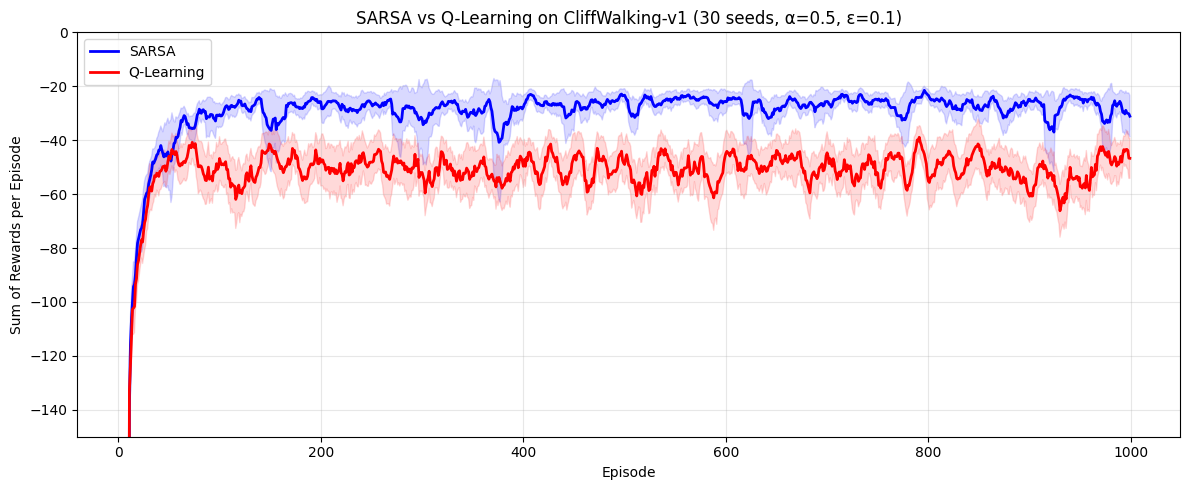

Saved figures/learning_curves.png


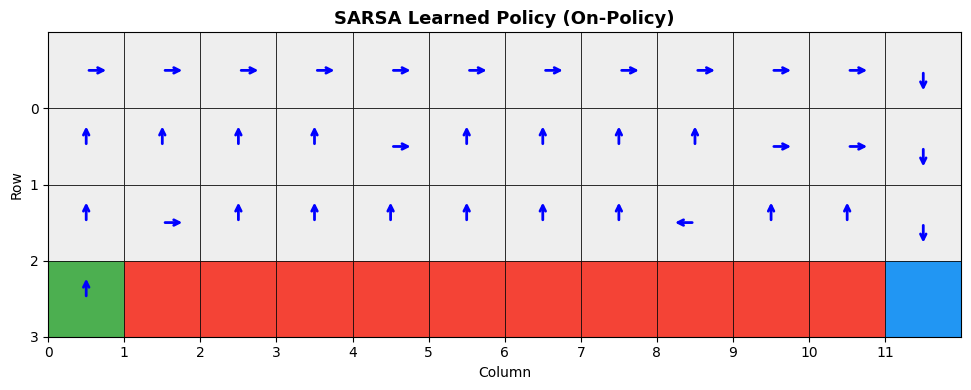

Saved figures/sarsa_policy.png


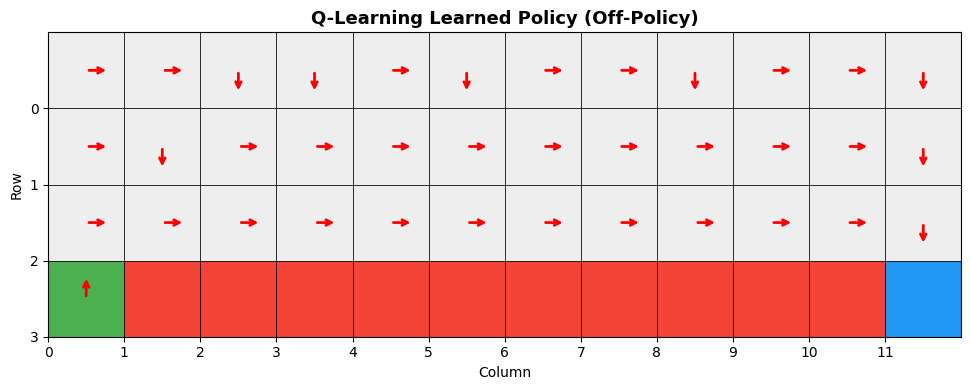

Saved figures/qlearning_policy.png


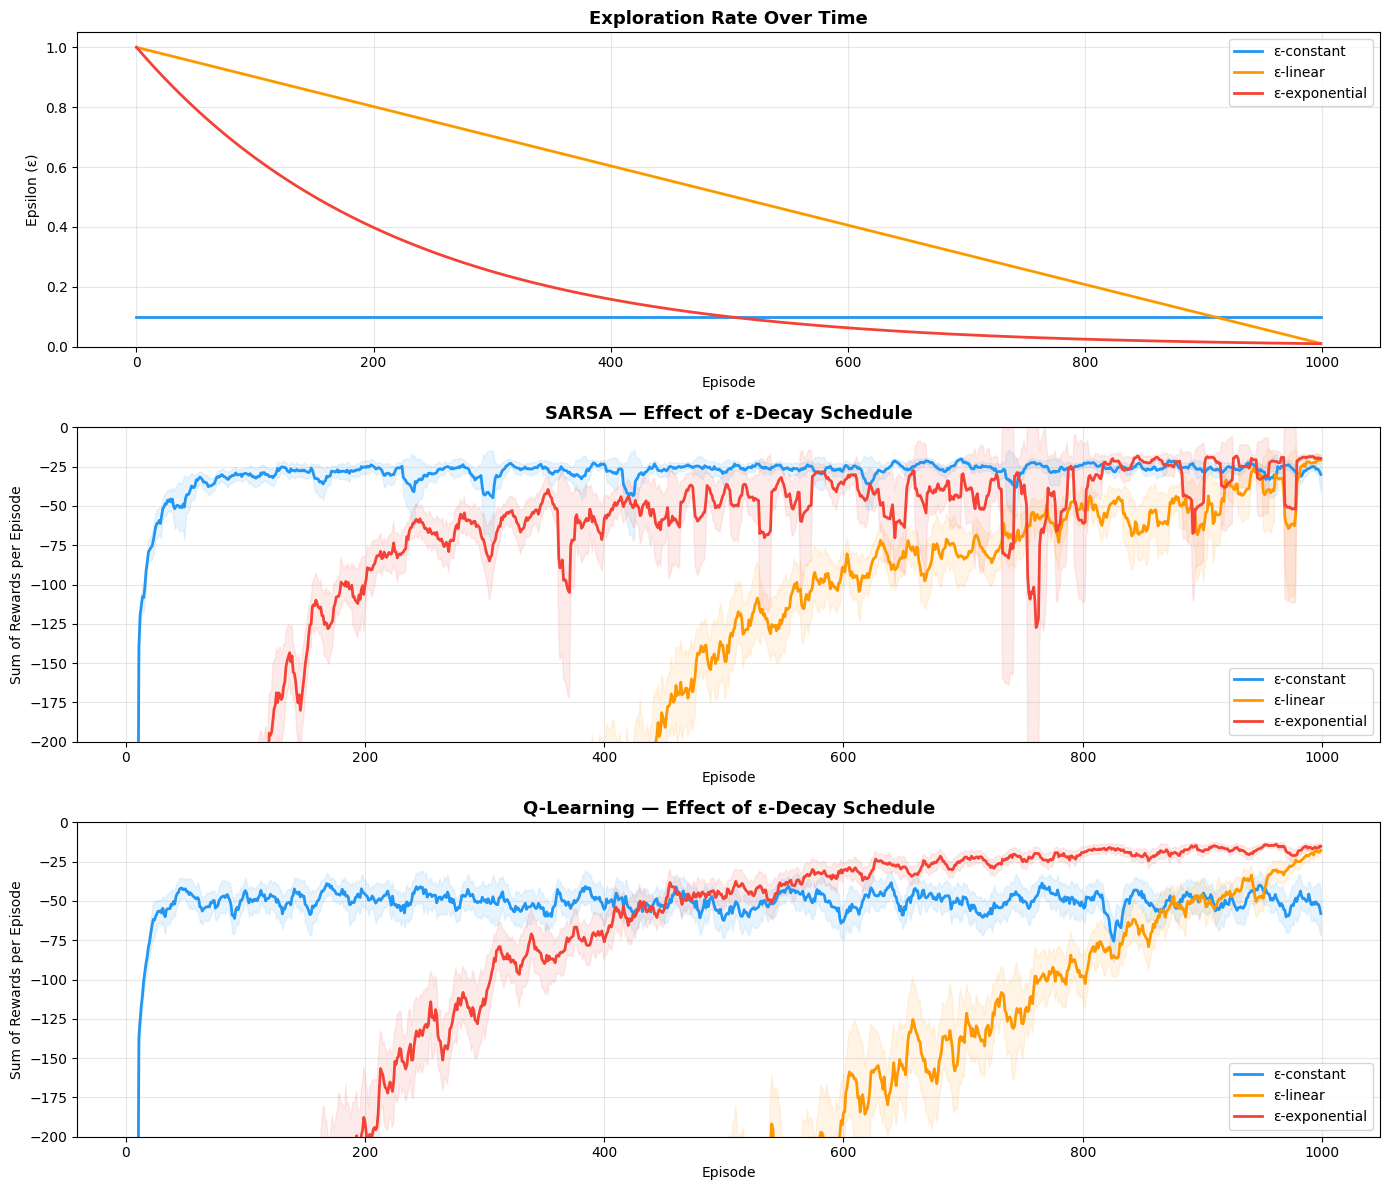

Saved figures/epsilon_decay.png

All figures saved to figures/ directory.


In [21]:
# Save figures for the report
import os
os.makedirs('figures', exist_ok=True)

# Figure 1: Learning curves with 95% CI
fig, ax = plt.subplots(figsize=(12, 5))
episodes_s, mean_s, ci_s = compute_stats(sarsa_all_rewards)
episodes_q, mean_q, ci_q = compute_stats(qlearn_all_rewards)
ax.plot(episodes_s, mean_s, color='blue', linewidth=2, label='SARSA')
ax.fill_between(episodes_s, mean_s - ci_s, mean_s + ci_s, color='blue', alpha=0.15)
ax.plot(episodes_q, mean_q, color='red', linewidth=2, label='Q-Learning')
ax.fill_between(episodes_q, mean_q - ci_q, mean_q + ci_q, color='red', alpha=0.15)
ax.set_xlabel('Episode')
ax.set_ylabel('Sum of Rewards per Episode')
ax.set_title(f'SARSA vs Q-Learning on CliffWalking-v1 ({N_SEEDS} seeds, α={ALPHA}, ε={EPSILON})')
ax.legend()
ax.set_ylim(-150, 0)
plt.tight_layout()
fig.savefig('figures/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/learning_curves.png')

# Figure 2: SARSA policy arrows
fig, ax = plt.subplots(figsize=(14, 4))
draw_grid(ax, 'SARSA Learned Policy (On-Policy)')
for s in range(NROWS * NCOLS):
    if s not in CLIFF and s != GOAL:
        row, col = state_to_grid(s)
        y = (NROWS - 1) - row
        best_action = int(np.argmax(Q_sarsa_vis[s]))
        cx, cy = col + 0.5, y + 0.5
        ax.annotate('', xy=(cx + ARROW_DX[best_action], cy + ARROW_DY[best_action]),
                    xytext=(cx, cy),
                    arrowprops=dict(arrowstyle='->', color='blue', lw=2))
plt.tight_layout()
fig.savefig('figures/sarsa_policy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/sarsa_policy.png')

# Figure 3: Q-learning policy arrows
fig, ax = plt.subplots(figsize=(14, 4))
draw_grid(ax, 'Q-Learning Learned Policy (Off-Policy)')
for s in range(NROWS * NCOLS):
    if s not in CLIFF and s != GOAL:
        row, col = state_to_grid(s)
        y = (NROWS - 1) - row
        best_action = int(np.argmax(Q_qlearn_vis[s]))
        cx, cy = col + 0.5, y + 0.5
        ax.annotate('', xy=(cx + ARROW_DX[best_action], cy + ARROW_DY[best_action]),
                    xytext=(cx, cy),
                    arrowprops=dict(arrowstyle='->', color='red', lw=2))
plt.tight_layout()
fig.savefig('figures/qlearning_policy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/qlearning_policy.png')

# Figure 4: Epsilon decay comparison (3-panel)
colors_decay = {'constant': '#2196F3', 'linear': '#FF9800', 'exponential': '#F44336'}
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
episodes_range = np.arange(N_EPISODES_HP)
ax_eps = axes[0]
for decay_type in DECAY_TYPES:
    eps_values = np.zeros(N_EPISODES_HP)
    for ep in range(N_EPISODES_HP):
        if decay_type == 'constant':
            eps_values[ep] = 0.1
        elif decay_type == 'linear':
            eps_values[ep] = max(0.01, 1.0 - (1.0 - 0.01) * ep / N_EPISODES_HP)
        elif decay_type == 'exponential':
            decay_rate = (0.01 / 1.0) ** (1 / N_EPISODES_HP)
            eps_values[ep] = max(0.01, 1.0 * (decay_rate ** ep))
    ax_eps.plot(episodes_range, eps_values, color=colors_decay[decay_type],
                linewidth=2, label=f'ε-{decay_type}')
ax_eps.set_xlabel('Episode')
ax_eps.set_ylabel('Epsilon (ε)')
ax_eps.set_title('Exploration Rate Over Time', fontsize=13, fontweight='bold')
ax_eps.legend()
ax_eps.set_ylim(0, 1.05)
ax_s = axes[1]
for decay_type in DECAY_TYPES:
    episodes, mean, ci = compute_stats(decay_results[decay_type]['sarsa'])
    c = colors_decay[decay_type]
    ax_s.plot(episodes, mean, color=c, linewidth=2, label=f'ε-{decay_type}')
    ax_s.fill_between(episodes, mean - ci, mean + ci, color=c, alpha=0.1)
ax_s.set_xlabel('Episode')
ax_s.set_ylabel('Sum of Rewards per Episode')
ax_s.set_title('SARSA — Effect of ε-Decay Schedule', fontsize=13, fontweight='bold')
ax_s.legend()
ax_s.set_ylim(-200, 0)
ax_q = axes[2]
for decay_type in DECAY_TYPES:
    episodes, mean, ci = compute_stats(decay_results[decay_type]['qlearn'])
    c = colors_decay[decay_type]
    ax_q.plot(episodes, mean, color=c, linewidth=2, label=f'ε-{decay_type}')
    ax_q.fill_between(episodes, mean - ci, mean + ci, color=c, alpha=0.1)
ax_q.set_xlabel('Episode')
ax_q.set_ylabel('Sum of Rewards per Episode')
ax_q.set_title('Q-Learning — Effect of ε-Decay Schedule', fontsize=13, fontweight='bold')
ax_q.legend()
ax_q.set_ylim(-200, 0)
plt.tight_layout()
fig.savefig('figures/epsilon_decay.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/epsilon_decay.png')

print('\nAll figures saved to figures/ directory.')
